# 🌊 BinWaves Duke (Propagation)

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
>
> **ℹ️ NOTE:** If bathymetry data for the study area is not available, free GEBCO bathymetry (~400 m resolution) can be used:
> - **Download GEBCO bathymetry data:** [https://download.gebco.net/](https://download.gebco.net/)
> - Example notebook for working with GEBCO data:  
>   [Download_GEBCO_Bathymetry_Data.ipynb](https://github.com/GeoOcean/BlueMath/blob/clean/binwaves/toolkit/data/Download_GEBCO_Bathymetry_Data.ipynb)
>
> **Outputs:**
> - SWAN case configuration in `.csv` format.
> - `Kp_coefficients.nc` file saved in the `outputs/` folder.
> 
> Create this `outputs/` folder if not available!

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk[waves]
  ```
 
---

<details open>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs and runs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details close>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** or **WHACS** datasets).

</details>

---

<details close>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

### 📌 In This Notebook: `BinWaves_Propagation.ipynb`

This notebook handles the **construction of the wave propagation library** by simulating wave cases.

### Steps:

- Generate wave conditions for all specified **frequencies** and **directions**.
- Set up and run SWAN simulations.
- Extract and save outputs from each simulation.
- Visualize the full wave library, including larger illustrative examples.

> ⚠️ **Coordinate System Note**  
> The BinWaves (SWAN) model can run in either **Spherical** or **Cartesian** coordinates:
> - Use **spherical coordinates** for areas larger than **100 km**.
> - Make sure your bathymetry file matches the coordinate system used in your simulation.

## Generate computational bathymetry

> ⚠️ **NOTE**  
> 
> - Functions expect coordinate columns to follow standard naming conventions.
> - For geographic coordinates, use: 'lon', 'lat', 'longitude', or 'latitude'.
> - For UTM coordinates, use: 'x', 'y', 'X', 'Y', 'cx', 'cy', 'easting', or 'northing'.
> - Ensure your data uses one of these names—otherwise, rename the coordinates accordingly
> - The bathymetry should have positive values for sea and negative values for land.

In [1]:
import xarray as xr
from utils.plotting import detect_coordinate_system

ds = xr.open_dataset("../../../../toolkit/data/outputs/gebco_2026_n45.0_s44.0_w-125.0_e-124.0.nc")

coords = detect_coordinate_system(ds)
is_geographic = coords["is_geographic"]
x_coord = coords["x_coord"]
y_coord = coords["y_coord"]

bathy = -(ds.transpose(y_coord, x_coord).sortby(y_coord, ascending=False).elevation)


In [2]:
import numpy as np
print(f"The resolution of the grid is approximately {np.diff(bathy.lon.values)[0]*111000:.2f} m")

resample_factor = 2
bathy = bathy.coarsen({x_coord: resample_factor, y_coord: resample_factor}, boundary="trim").mean()
print(f"The resolution of the grid after the resample factor of {resample_factor} is approximately {np.diff(bathy.lon.values)[0]*111000:.2f} m")


The resolution of the grid is approximately 462.50 m
The resolution of the grid after the resample factor of 2 is approximately 925.00 m


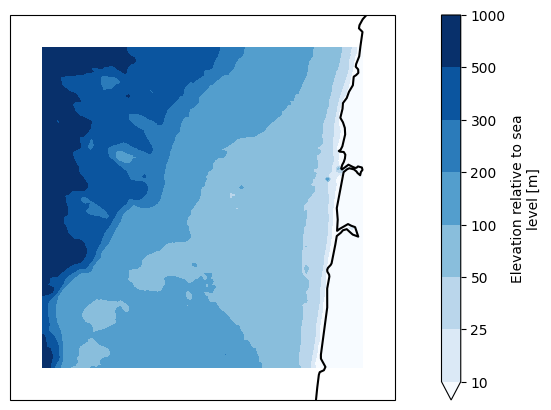

In [3]:
from utils.plotting import plot_selected_bathy

plot_selected_bathy(bathy=bathy, buoys=None)

## SWAN Grid Parameters

This section defines the computational grid for running the SWAN model:

- **`xpc`, `ypc`**: Origin coordinates of the grid (in meters for Cartesian, degrees for spherical).  
  - Default = `0.0` for Cartesian; required for spherical.

- **`alpc`**: Angle of the positive x-axis (degrees, Cartesian convention).  
  - Default = `0.0`.

- **`xlenc`, `ylenc`**: Grid length in the x- and y-directions.  
  - Units: meters (Cartesian), degrees (spherical).  

- **`mxc`, `myc`**: Number of grid cells in x- and y-directions (1 less than number of grid points).  
  - In 1D mode, `myc` = `0`.

<center>
    <img src="./assets/SWAN_grid.png" width="80%">
</center>

In [4]:
# COMPUTATIONAL GRID PARAMETERS
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

alpc = 0
grid_parameters = generate_grid_parameters(bathy, alpc)
grid_parameters

{'xpc': -124.99583333333334,
 'ypc': 44.00416666666666,
 'alpc': 0,
 'xlenc': 0.9916666666666742,
 'ylenc': 0.9916666666666671,
 'mxc': 119,
 'myc': 119,
 'xpinp': -124.99583333333334,
 'ypinp': 44.00416666666666,
 'alpinp': 0,
 'mxinp': 119,
 'myinp': 119,
 'dxinp': 0.008333333333339965,
 'dyinp': 0.00833333333333286}

## Desired locations for Model outputs

> ⚠️ **NOTE**  
> 
> - Output location spacing (out_dx, out_dy) can be specified. If not provided, the output locations will use the same spacing as the SWAN grid. However, for large domains or very fine SWAN grids, it is recommended to decrease the output spacing to reduce computational cost, at least at tasting stages.

In [5]:
# OUTPUT GRID LOCATIONS (KPS)
import numpy as np
from utils.operations import locations_grid_outputs

locations = locations_grid_outputs(grid_parameters, out_dx=0.15, out_dy=0.15)
# Combine grid locations with buoy locations
# buoy_coords = np.array(list(buoys_geo.values()))
locations = np.vstack((locations))#, buoy_coords))

# Keep only locations that fall on sea (bathy > 0, per the sign convention
# set above: positive = sea, negative = land). Output points on land come
# back from SWAN as NODATA blocks, and wavespectra's read_swan() does not
# reshape a LONLAT list mixing NODATA (land) with real data correctly onto
# a (lat, lon) grid - it ends up duplicating/shifting values between points
# and losing whole rows. Restricting the output locations to sea points
# avoids NODATA entirely.
bathy_at_locations = bathy.sel(
    {x_coord: xr.DataArray(locations[:, 0], dims="site"),
     y_coord: xr.DataArray(locations[:, 1], dims="site")},
    method="nearest",
).values
is_sea = bathy_at_locations > 0
print(f"Keeping {is_sea.sum()} of {len(locations)} output locations (sea only)")
locations = locations[is_sea]
locations

Keeping 56 of 64 output locations (sea only)


array([[-124.99583333,   44.00416667],
       [-124.85416667,   44.00416667],
       [-124.7125    ,   44.00416667],
       [-124.57083333,   44.00416667],
       [-124.42916667,   44.00416667],
       [-124.2875    ,   44.00416667],
       [-124.14583333,   44.00416667],
       [-124.99583333,   44.14583333],
       [-124.85416667,   44.14583333],
       [-124.7125    ,   44.14583333],
       [-124.57083333,   44.14583333],
       [-124.42916667,   44.14583333],
       [-124.2875    ,   44.14583333],
       [-124.14583333,   44.14583333],
       [-124.99583333,   44.2875    ],
       [-124.85416667,   44.2875    ],
       [-124.7125    ,   44.2875    ],
       [-124.57083333,   44.2875    ],
       [-124.42916667,   44.2875    ],
       [-124.2875    ,   44.2875    ],
       [-124.14583333,   44.2875    ],
       [-124.99583333,   44.42916667],
       [-124.85416667,   44.42916667],
       [-124.7125    ,   44.42916667],
       [-124.57083333,   44.42916667],
       [-124.42916667,   

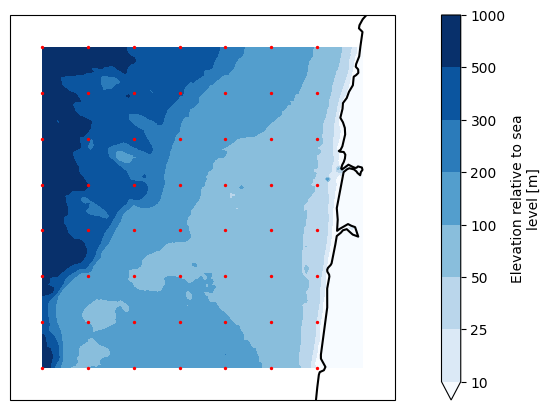

In [6]:
import matplotlib.pyplot as plt
from utils.plotting import detect_coordinate_system, plot_selected_bathy

# Get the projection from your bathy
coords = detect_coordinate_system(bathy)
proj = coords["proj"]
transform = coords["transform"]

# Create the plot with bathymetry and buoys
fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": proj})
plot_selected_bathy(bathy=bathy, buoys=None, ax=ax)

ax.scatter(
    locations[:, 0],
    locations[:, 1],
    color="red",
    s=2,
    label="Output Locations",
    transform=coords["transform"],
)

## Build and Run SWAN Cases

> 🧘 **NOTE:** If directions and frequencies are used as default, You’re all set! The Bluemath Toolkit takes care of building and running the SWAN cases for you.

In [7]:
#offshore_spectra = xr.open_dataset(
#    "../../../../toolkit/data/outputs/offshore_spectra.nc"
#)

In [8]:
# To speed up the process for the course, we resample the spectra to 1/3 of its resolution in frequency and direction
#offshore_spectra = (
#    offshore_spectra
#    .coarsen(freq=3, dir=3, boundary="trim")
#    .mean()
#)

#offshore_spectra

In [9]:
#freq = np.sort(offshore_spectra.spec.freq.values)
#dir = np.sort(offshore_spectra.spec.dir.values)
#print("freq", freq)
#print("dir", dir)

In [10]:
from bluemath_tk.waves.binwaves import generate_swan_cases

swan_cases_df = (
    generate_swan_cases(
        # Different directions and frequencies can be specified. If not provided the model will use the default values.
        #frequencies_array=freq,
        #direction_range=(130, 400),
        direction_divisions=12,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df["dir"] = swan_cases_df["dir"] % 360
swan_cases_df.head()

,dir,freq,hs,tp,spr,gamma
0,15.0,0.035000,1.0,28.5714,2.0,50.0
1,15.0,0.038487,1.0,25.9828,2.0,50.0
2,15.0,0.042321,1.0,23.6287,2.0,50.0
3,15.0,0.046538,1.0,21.4878,2.0,50.0
4,15.0,0.051175,1.0,19.5410,2.0,50.0


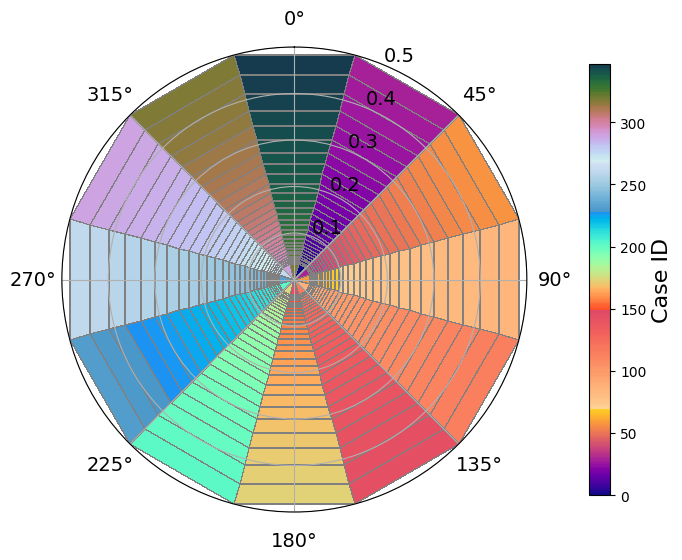

In [11]:
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid. Specific directions sectors can be specified.
plot_selected_cases_grid(
    frequencies=np.unique(swan_cases_df["freq"]),
    directions=np.unique(swan_cases_df["dir"]),
    figsize=(8, 8),
)

In [12]:
from bluemath_tk.wrappers.swan.swan_wrapper import generate_fixed_parameters

fixed_parameters = generate_fixed_parameters(grid_parameters, swan_cases_df["freq"], swan_cases_df["dir"])
fixed_parameters

Distribución direccional: CIRCLE


{'xpc': -124.99583333333334,
 'ypc': 44.00416666666666,
 'alpc': 0,
 'xlenc': 0.9916666666666742,
 'ylenc': 0.9916666666666671,
 'mxc': 119,
 'myc': 119,
 'xpinp': -124.99583333333334,
 'ypinp': 44.00416666666666,
 'alpinp': 0,
 'mxinp': 119,
 'myinp': 119,
 'dxinp': 0.008333333333339965,
 'dyinp': 0.00833333333333286,
 'dir_dist': 'CIRCLE',
 'dir1': None,
 'dir2': None,
 'freq_discretization': 29,
 'dir_discretization': 12,
 'mdc': 12,
 'flow': 0.035,
 'fhigh': 0.5}

In [13]:
import os

from bluemath_tk.wrappers.swan.swan_wrapper import BinWavesWrapper

swan_wrapper = BinWavesWrapper(
    templates_dir="templates",
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir="NEWPORT_CASES",
    depth_array=bathy.values,
    locations=locations.T,
)

2026-09-29 16:41:33,899 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2026-09-29 16:41:33,900 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2026-09-29 16:41:33,901 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2026-09-29 16:41:33,902 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2026-09-29 16:41:33,903 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2026-09-29 16:41:33,903 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [14]:
# Build the input files (needed to regenerate cases with the filtered,
# sea-only output locations)
swan_wrapper.build_cases(mode="one_by_one")
swan_cases_df.to_csv(os.path.join("NEWPORT_CASES", "swan_cases.csv"), index=False)

## Execute SWAN

> ⏰ **Note:** To monitor the progress of your runs, you can execute the following cell anytime to check how many SWAN cases have completed (100% simulation finished).  
> It may take a while for the first cases to finish, so feel free to run the cell multiple times to stay updated.  
> Once all cases have reached 100%, you can proceed with the rest of the code.  
> You can also run the next cells even if only a few cases have completed, to check that everything is working as expected.



In [15]:
# Run the model
run = False

if run:
    swan_wrapper.run_cases_bulk(
        launcher="sbatch --array=0-697%50 sbatch_example.sh"
    )
    swan_wrapper.run_cases_in_background(launcher="swan_serial.exe", num_workers=4)
else:
    swan_wrapper.load_cases()  # If you have already run the model, you can load the results without running it again.

In [16]:
if run:
    swan_wrapper.monitor_cases(value_counts="simple") 

In [17]:
# Post-process the output files
cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters['Hsig'] = cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,)

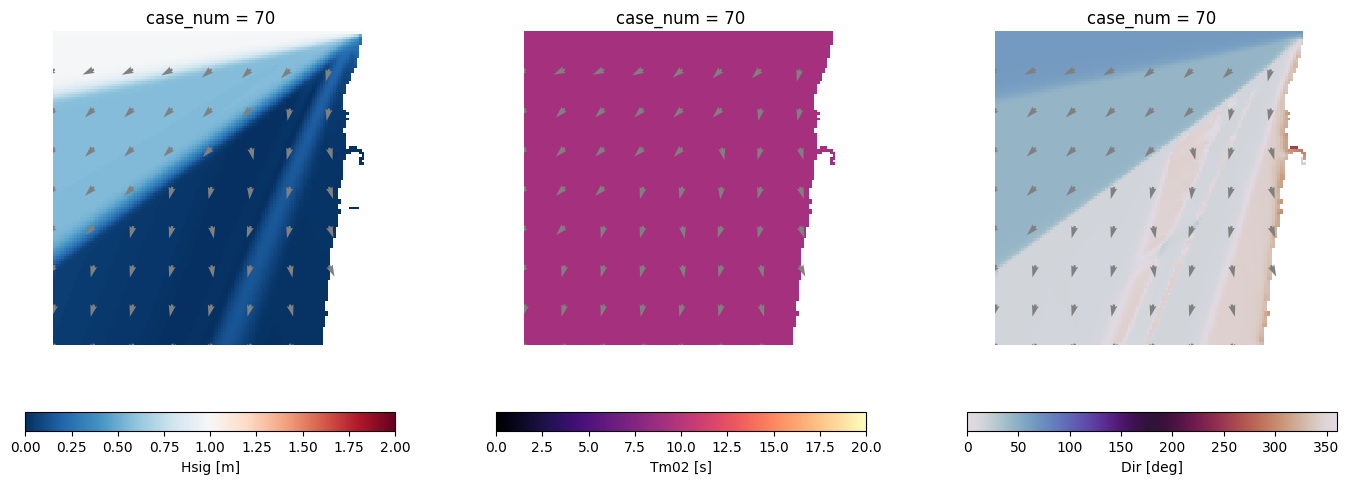

In [18]:
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=70),
    step=15,
    vmax_hs = 2,
    vmin_hs = 0
)

## Plot ALL pre-run cases

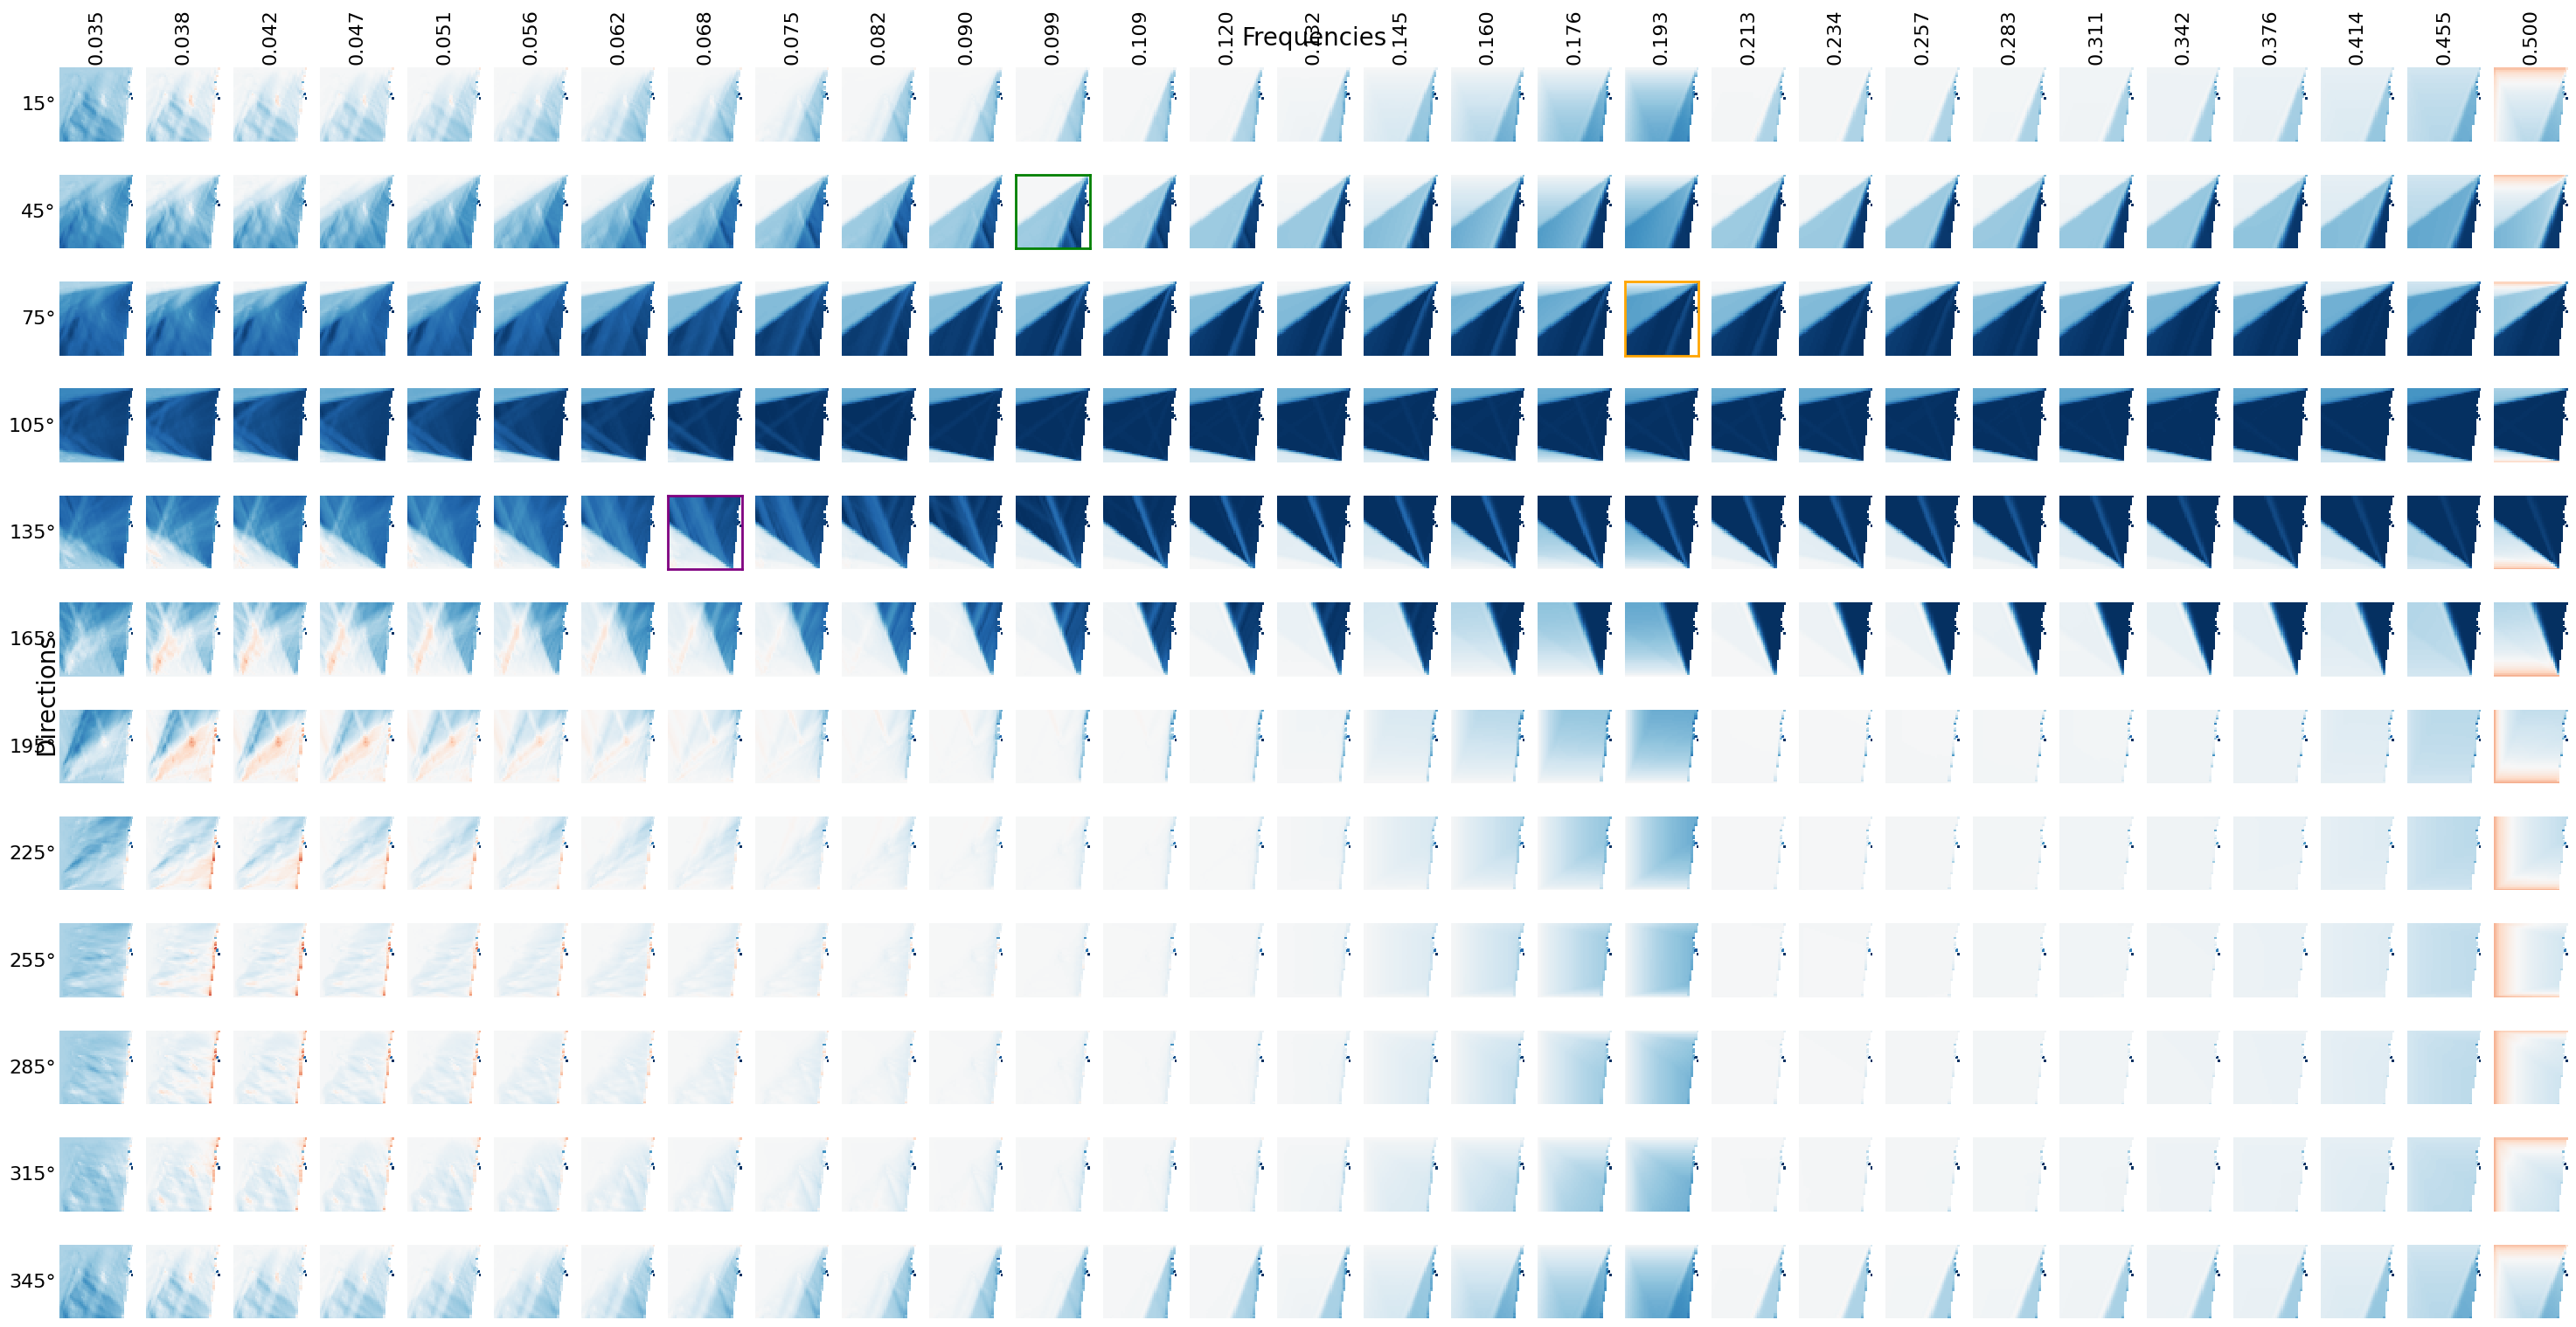

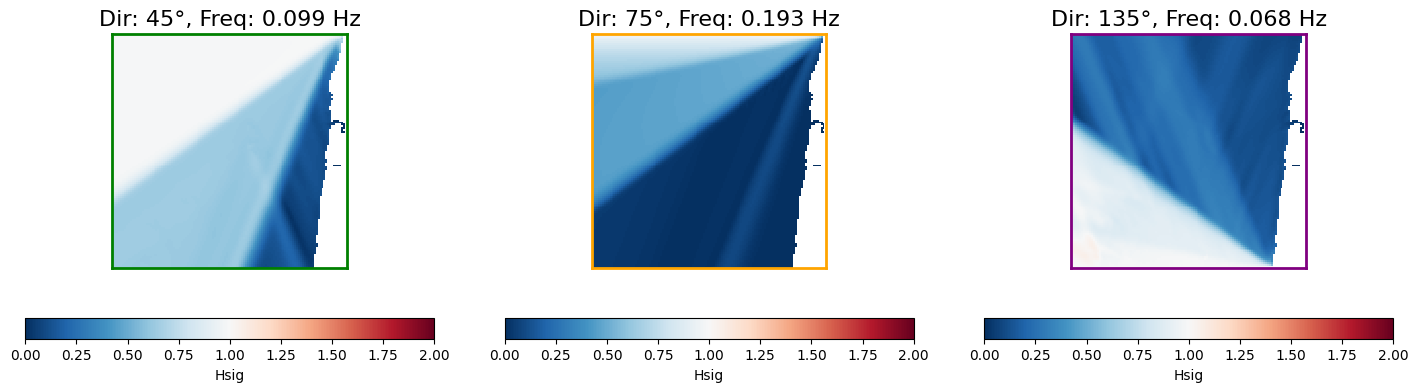

In [19]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig,
    cases_to_plot=[40, 76, 123],
    num_directions=len(swan_cases_df["dir"].unique()),
    num_frequencies=len(swan_cases_df["freq"].unique()),
    directions=swan_cases_df["dir"].unique(),
    frequencies=swan_cases_df["freq"].unique(),
)

## Extract kp coefficients

In [24]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)

In [34]:
site = np.arange(len(swan_wrapper.locations))

kp_coefficients_sites = (
    kp_coefficients.sel(lon=xr.DataArray(swan_wrapper.locations[:, 0], dims="site", coords={"site": site}),
        lat=xr.DataArray(swan_wrapper.locations[:, 1], dims="site", coords={"site": site},), method="nearest",
    ).drop_vars("time", errors="ignore")
    .to_dataset(name="kps")
    .assign_coords(
        coord_x=("site", swan_wrapper.locations[:, 0]),
        coord_y=("site", swan_wrapper.locations[:, 1]),
    )
)
kp_coefficients_sites.to_netcdf("outputs/kp_coefficients.nc")

## From offshore wave train to site response

For a single case (a single offshore frequency/direction bin), this shows the resulting `Kp` response spectrum at one output site.

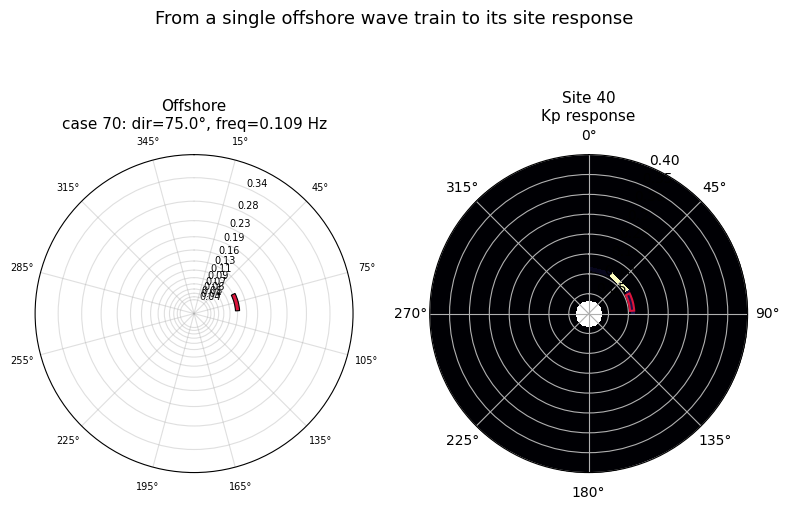

In [33]:
from utils.plotting import plot_case_to_site_response

# Case and output site used to illustrate the BinWaves idea: a single
# offshore wave train (one freq/dir case) produces a full response
# spectrum at each output site
case_num_to_plot = 70
site_to_plot = kp_coefficients_sites.site.values[40]

fig, axes = plot_case_to_site_response(
    swan_cases_df=swan_cases_df,
    kp_coefficients=kp_coefficients_sites,
    case_num=case_num_to_plot,
    site=site_to_plot,
    dir_width_deg=270 / 12,  # matches direction_range=(130, 400), direction_divisions=12
    figsize=(8, 6),
    ylim=0.4,
)